Train shape: (175341, 45)
Test shape: (82332, 45)
Classes: ['Backdoor' 'Critical' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance']
Applied balanced class weights to training data.

=== Classification Report ===
                precision    recall  f1-score   support

      Backdoor       0.06      0.79      0.11       583
      Critical       0.10      0.37      0.16      1099
           DoS       0.40      0.20      0.27      4089
      Exploits       0.82      0.60      0.69     11132
       Fuzzers       0.25      0.69      0.37      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.99      0.59      0.74     37000
Reconnaissance       0.85      0.85      0.85      3496

      accuracy                           0.68     82332
     macro avg       0.56      0.63      0.52     82332
  weighted avg       0.86      0.68      0.73     82332


Macro Recall: 0.632856860662764


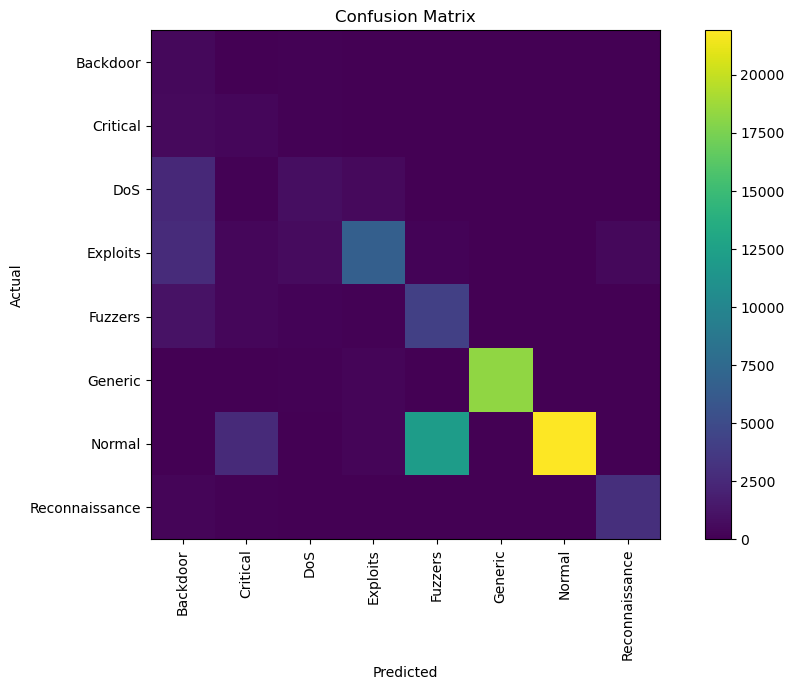


=== TOP 10 HIGH-RISK ALERTS ===
      predicted_attack  max_probability  risk_score alert_level
2064          Exploits         0.997673    3.990693    Critical
2062          Exploits         0.997673    3.990693    Critical
9059          Exploits         0.996714    3.986854    Critical
9060          Exploits         0.996714    3.986854    Critical
44815         Exploits         0.996486    3.985942    Critical
44811         Exploits         0.996486    3.985942    Critical
53216         Exploits         0.996312    3.985247    Critical
53213         Exploits         0.996312    3.985247    Critical
10992         Exploits         0.996303    3.985212    Critical
10353         Exploits         0.996303    3.985212    Critical


In [1]:
# ==============================
# 1. IMPORTS
# ==============================
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

# ==============================
# 2. LOAD DATA
# ==============================
# UNSW-15
train = pd.read_csv("/Users/baldskull/Downloads/OneDrive_1_25-03-2026/UNSW_NB15_training-set.csv")
test = pd.read_csv("/Users/baldskull/Downloads/OneDrive_1_25-03-2026/UNSW_NB15_testing-set.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# ==============================
# 3. CLEAN LABELS
# ==============================
train['attack_cat'] = train['attack_cat'].str.strip()
test['attack_cat'] = test['attack_cat'].str.strip()

# ==============================
# 4. MERGE RARE CLASSES
# ==============================
def merge_classes(x):
    if x in ["Worms", "Shellcode", "Analysis"]:
        return "Critical"
    return x

train['attack_cat'] = train['attack_cat'].apply(merge_classes)
test['attack_cat'] = test['attack_cat'].apply(merge_classes)

# ==============================
# 5. ONE-HOT ENCODING
# ==============================
categorical_cols = ['proto', 'service', 'state']

train = pd.get_dummies(train, columns=categorical_cols)
test = pd.get_dummies(test, columns=categorical_cols)

train, test = train.align(test, join='left', axis=1, fill_value=0)

# ==============================
# 6. FEATURES & TARGET
# ==============================
X_train = train.drop(['attack_cat', 'label', 'id'], axis=1)
y_train = train['attack_cat']

X_test = test.drop(['attack_cat', 'label', 'id'], axis=1)
y_test = test['attack_cat']

# ==============================
# 7. SCALE
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 8. LABEL ENCODING
# ==============================
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Classes:", le.classes_)

# ==============================
# 9. CLASS WEIGHTS (Replaces SMOTE)
# ==============================
# Compute balanced sample weights to heavily penalize errors on minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print("Applied balanced class weights to training data.")

# ==============================
# 10. XGBOOST MODEL
# ==============================
model = XGBClassifier(
    n_estimators=300,        # Increased from 200
    max_depth=6,             # Decreased from 8 to reduce overfitting
    learning_rate=0.05,      # Decreased from 0.1 for more stable learning
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

# Fit using the sample weights
model.fit(X_train, y_train, sample_weight=sample_weights)

# ==============================
# 11. PREDICTIONS
# ==============================
y_pred = model.predict(X_test)

y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

# ==============================
# 12. EVALUATION
# ==============================
print("\n=== Classification Report ===")
print(classification_report(y_test_labels, y_pred_labels))

recall = recall_score(y_test_labels, y_pred_labels, average='macro')
print("\nMacro Recall:", recall)

# ==============================
# 13. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test_labels, y_pred_labels)

plt.figure(figsize=(10, 7))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = le.classes_
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ==============================
# 14. RISK SCORING
# ==============================
probs = model.predict_proba(X_test)
probs_df = pd.DataFrame(probs, columns=le.classes_)

results = test.copy().reset_index(drop=True)

results['predicted_attack'] = y_pred_labels
results['max_probability'] = probs_df.max(axis=1)

def risk_score(row):
    attack = row['predicted_attack']
    prob = row['max_probability']
    
    if attack == "Normal":
        weight = 1
    elif attack in ["Reconnaissance", "Generic"]:
        weight = 2
    elif attack in ["DoS", "Fuzzers"]:
        weight = 3
    else:
        weight = 4   # Critical + Exploits + Backdoor
    
    return weight * prob

results['risk_score'] = results.apply(risk_score, axis=1)

# ==============================
# 15. ALERT LEVELS
# ==============================
results['alert_level'] = pd.cut(
    results['risk_score'],
    bins=[0, 1, 2, 3, 5],
    labels=["Low", "Medium", "High", "Critical"]
)

# ==============================
# 16. TOP 10 HIGH-RISK ALERTS
# ==============================
top10 = results.sort_values(by='risk_score', ascending=False).tail(10)

print("\n=== TOP 10 HIGH-RISK ALERTS ===")
print(top10[['predicted_attack', 'max_probability', 'risk_score', 'alert_level']])